<a href="https://colab.research.google.com/github/victor7miguel7/Projeto-Computa-o-Visual-1VA/blob/main/Projeto_Comp_Visual_1VA_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q torch torchvision opencv-python matplotlib tqdm

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.transforms as T
from torchvision.datasets import VOCSegmentation

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# Carrega dataset

In [3]:
dataset = VOCSegmentation(
    root=".",
    year="2012",
    image_set="train",
    download=True
)

print("Total de imagens:", len(dataset))

100%|██████████| 2.00G/2.00G [00:52<00:00, 37.8MB/s]


Total de imagens: 1464


# Carrega Modelo

In [4]:
class SimpleSegNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )

    def forward(self, x):
        return self.net(x)

 # Função de Mascara e Pontos


In [5]:
def to_binary_mask(mask):
    mask = np.array(mask)
    return (mask > 0).astype(np.uint8)


def sample_random_points(mask, num_points):
    h, w = mask.shape
    pts = []

    for _ in range(num_points):
        y = np.random.randint(0, h)
        x = np.random.randint(0, w)
        pts.append((x, y, mask[y, x]))

    return pts


def sample_edge_points(mask, num_points):
    edges = cv2.Canny((mask*255).astype(np.uint8), 100, 200)

    ys, xs = np.where(edges > 0)

    if len(xs) < num_points:
        return sample_random_points(mask, num_points)

    idx = np.random.choice(len(xs), num_points, replace=False)

    return [(xs[i], ys[i], mask[ys[i], xs[i]]) for i in idx]


def sample_hybrid_points(mask, num_points, edge_ratio=0.5):
    num_edge = int(num_points * edge_ratio)
    num_random = num_points - num_edge

    edge_pts = sample_edge_points(mask, num_edge)
    rand_pts = sample_random_points(mask, num_random)

    return edge_pts + rand_pts

# Loss

In [6]:
def point_loss(pred, points):
    loss = 0
    for (x, y, label) in points:
        pred_val = pred[0,0,y,x]
        target = torch.tensor(label).float().to(pred.device)

        loss += F.binary_cross_entropy_with_logits(pred_val, target)

    return loss / len(points)


def full_mask_loss(pred, mask):
    return F.binary_cross_entropy_with_logits(pred, mask)

# Metricas

In [7]:
def iou(pred, mask):
    pred_bin = (pred > 0.5).astype(np.uint8)
    intersection = (pred_bin & mask).sum()
    union = (pred_bin | mask).sum()
    return intersection / (union + 1e-6)


def dice(pred, mask):
    pred_bin = (pred > 0.5).astype(np.uint8)
    intersection = (pred_bin & mask).sum()
    return (2 * intersection) / (pred_bin.sum() + mask.sum() + 1e-6)

# Treinamento

In [8]:
def train_model(img_tensor, mask_tensor, mask_np, mode="full", num_points=10, epochs=50):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = SimpleSegNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    img_tensor = img_tensor.to(device)
    mask_tensor = mask_tensor.to(device)

    if mode == "random":
        points = sample_random_points(mask_np, num_points)

    elif mode == "edge":
        points = sample_edge_points(mask_np, num_points)

    elif mode == "hybrid":
        points = sample_hybrid_points(mask_np, num_points, edge_ratio=0.5)

    for _ in range(epochs):
        pred = model(img_tensor)

        if mode == "full":
            loss = full_mask_loss(pred, mask_tensor)
        else:
            loss = point_loss(pred, points)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        pred = torch.sigmoid(model(img_tensor))[0,0].cpu().numpy()

    return pred

# LOOP nas Imagens para Experimentos

In [9]:
transform = T.Compose([T.ToTensor()])

NUM_IMAGES = 20
POINTS_LIST = [10, 20, 50, 75]

results = {
    "full": [],
    "random": {p: [] for p in POINTS_LIST},
    "edge": {p: [] for p in POINTS_LIST},
    "hybrid": {p: [] for p in POINTS_LIST}
}

for i in tqdm(range(NUM_IMAGES)):
    img, mask = dataset[i]

    img_tensor = transform(img).unsqueeze(0)
    mask_np = to_binary_mask(mask)
    mask_tensor = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0).float()

    # FULL
    pred_full = train_model(img_tensor, mask_tensor, mask_np, mode="full")
    results["full"].append({
        "iou": iou(pred_full, mask_np),
        "dice": dice(pred_full, mask_np)
    })

    for p in POINTS_LIST:
        pred_r = train_model(img_tensor, mask_tensor, mask_np, "random", p)
        pred_e = train_model(img_tensor, mask_tensor, mask_np, "edge", p)
        pred_h = train_model(img_tensor, mask_tensor, mask_np, "hybrid", p)

        results["random"][p].append({
            "iou": iou(pred_r, mask_np),
            "dice": dice(pred_r, mask_np)
        })

        results["edge"][p].append({
            "iou": iou(pred_e, mask_np),
            "dice": dice(pred_e, mask_np)
        })

        results["hybrid"][p].append({
            "iou": iou(pred_h, mask_np),
            "dice": dice(pred_h, mask_np)
        })

100%|██████████| 20/20 [47:22<00:00, 142.14s/it]


# Resultados

In [10]:
def avg_metrics(list_dict):
    ious = [x["iou"] for x in list_dict]
    dices = [x["dice"] for x in list_dict]
    return np.mean(ious), np.mean(dices)


print("=== FULL MASK ===")
iou_full, dice_full = avg_metrics(results["full"])
print("IoU:", iou_full, "Dice:", dice_full)


print("\n=== RANDOM ===")
for p in POINTS_LIST:
    iou_r, dice_r = avg_metrics(results["random"][p])
    print(f"{p} pontos → IoU: {iou_r:.3f}, Dice: {dice_r:.3f}")


print("\n=== EDGE ===")
for p in POINTS_LIST:
    iou_e, dice_e = avg_metrics(results["edge"][p])
    print(f"{p} pontos → IoU: {iou_e:.3f}, Dice: {dice_e:.3f}")


print("\n=== HYBRID ===")
for p in POINTS_LIST:
    iou_h, dice_h = avg_metrics(results["hybrid"][p])
    print(f"{p} pontos → IoU: {iou_h:.3f}, Dice: {dice_h:.3f}")

=== FULL MASK ===
IoU: 0.37751152773211444 Dice: 0.4531476360363307

=== RANDOM ===
10 pontos → IoU: 0.287, Dice: 0.380
20 pontos → IoU: 0.275, Dice: 0.351
50 pontos → IoU: 0.332, Dice: 0.423
75 pontos → IoU: 0.328, Dice: 0.410

=== EDGE ===
10 pontos → IoU: 0.263, Dice: 0.377
20 pontos → IoU: 0.163, Dice: 0.257
50 pontos → IoU: 0.187, Dice: 0.293
75 pontos → IoU: 0.212, Dice: 0.317

=== HYBRID ===
10 pontos → IoU: 0.226, Dice: 0.336
20 pontos → IoU: 0.307, Dice: 0.427
50 pontos → IoU: 0.346, Dice: 0.462
75 pontos → IoU: 0.348, Dice: 0.466


# Grafico Resultados

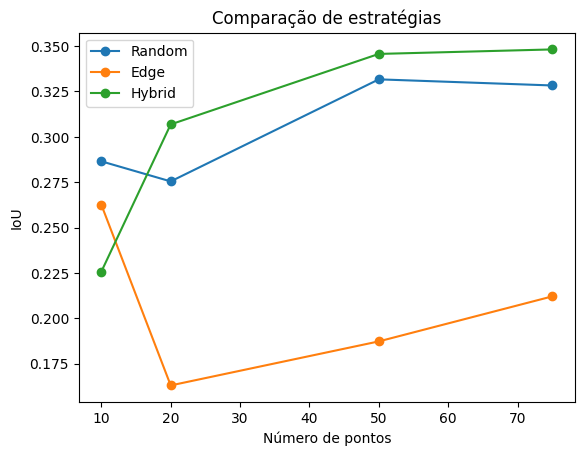

In [11]:
iou_random = []
iou_edge = []
iou_hybrid = []

for p in POINTS_LIST:
    iou_r, _ = avg_metrics(results["random"][p])
    iou_e, _ = avg_metrics(results["edge"][p])
    iou_h, _ = avg_metrics(results["hybrid"][p])

    iou_random.append(iou_r)
    iou_edge.append(iou_e)
    iou_hybrid.append(iou_h)

plt.plot(POINTS_LIST, iou_random, marker='o', label="Random")
plt.plot(POINTS_LIST, iou_edge, marker='o', label="Edge")
plt.plot(POINTS_LIST, iou_hybrid, marker='o', label="Hybrid")

plt.xlabel("Número de pontos")
plt.ylabel("IoU")
plt.title("Comparação de estratégias")
plt.legend()
plt.show()

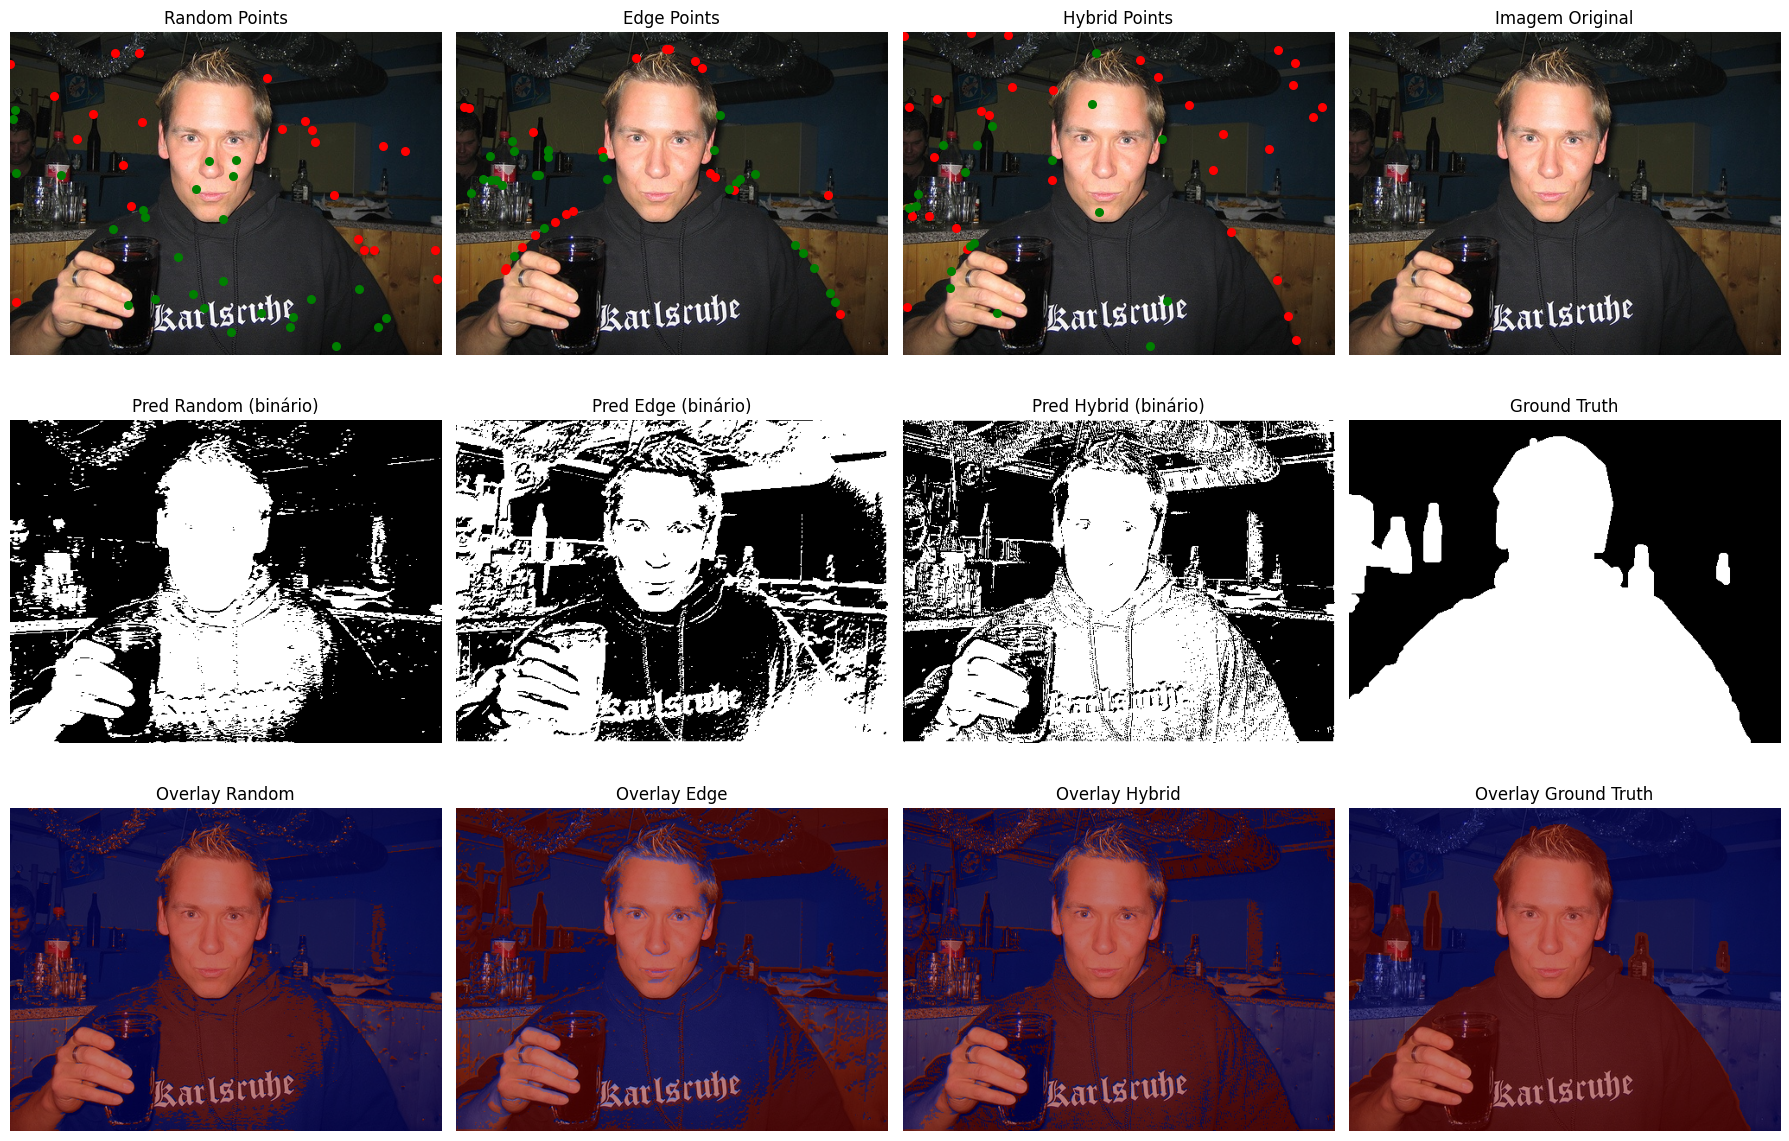

In [15]:
def plot_points(ax, img, points, title):
    ax.imshow(img)
    for (x, y, label) in points:
        color = 'green' if label == 1 else 'red'
        ax.scatter(x, y, c=color, s=30)
    ax.set_title(title)
    ax.axis("off")


def overlay_mask(ax, img, pred, title):
    ax.imshow(img)
    ax.imshow(pred, cmap='jet', alpha=0.5)
    ax.set_title(title)
    ax.axis("off")


def show_example(dataset, idx=0, n_points=10):
    img, mask = dataset[idx]
    img_np = np.array(img)
    img_tensor = T.ToTensor()(img).unsqueeze(0)

    mask_np = to_binary_mask(mask)
    mask_tensor = torch.tensor(mask_np).unsqueeze(0).unsqueeze(0).float()

    pts_random = sample_random_points(mask_np, n_points)
    pts_edge   = sample_edge_points(mask_np, n_points)
    pts_hybrid = sample_hybrid_points(mask_np, n_points)

    pred_random = train_model(img_tensor, mask_tensor, mask_np, "random", n_points)
    pred_edge   = train_model(img_tensor, mask_tensor, mask_np, "edge",   n_points)
    pred_hybrid = train_model(img_tensor, mask_tensor, mask_np, "hybrid", n_points)

    pred_random_bin = (pred_random > 0.5).astype(np.uint8)
    pred_edge_bin   = (pred_edge   > 0.5).astype(np.uint8)
    pred_hybrid_bin = (pred_hybrid > 0.5).astype(np.uint8)

    fig, axs = plt.subplots(3, 4, figsize=(18, 12))

    # --- Linha 1: imagem + pontos amostrados ---
    plot_points(axs[0, 0], img_np, pts_random, "Random Points")
    plot_points(axs[0, 1], img_np, pts_edge,   "Edge Points")
    plot_points(axs[0, 2], img_np, pts_hybrid,  "Hybrid Points")
    axs[0, 3].imshow(img_np)
    axs[0, 3].set_title("Imagem Original")
    axs[0, 3].axis("off")

    # --- Linha 2: máscaras binárias (vmin/vmax corrigido) ---
    axs[1, 0].imshow(pred_random_bin, cmap='gray', vmin=0, vmax=1)
    axs[1, 0].set_title("Pred Random (binário)")
    axs[1, 0].axis("off")

    axs[1, 1].imshow(pred_edge_bin, cmap='gray', vmin=0, vmax=1)
    axs[1, 1].set_title("Pred Edge (binário)")
    axs[1, 1].axis("off")

    axs[1, 2].imshow(pred_hybrid_bin, cmap='gray', vmin=0, vmax=1)
    axs[1, 2].set_title("Pred Hybrid (binário)")
    axs[1, 2].axis("off")

    axs[1, 3].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
    axs[1, 3].set_title("Ground Truth")
    axs[1, 3].axis("off")

    # --- Linha 3: overlay sobre imagem original ---
    overlay_mask(axs[2, 0], img_np, pred_random_bin, "Overlay Random")
    overlay_mask(axs[2, 1], img_np, pred_edge_bin,   "Overlay Edge")
    overlay_mask(axs[2, 2], img_np, pred_hybrid_bin,  "Overlay Hybrid")
    axs[2, 3].imshow(img_np)
    axs[2, 3].imshow(mask_np, cmap='jet', alpha=0.5)
    axs[2, 3].set_title("Overlay Ground Truth")
    axs[2, 3].axis("off")

    plt.tight_layout()
    plt.show()


show_example(dataset, idx=5, n_points=50)